## **EDA File Credit**
## Credit Risk Prediction Across Two Financial Products

Object: Can we build and compare machine learning models to predict default risk across different credit products?

Original data set can be found here:
[Default of Credit Card Clients Dataset](https://www.kaggle.com/datasets/uciml/default-of-credit-card-clients-dataset)


### 1. Packages and Loading data

In [95]:
# Importing packages
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Train-test split and model selection
from sklearn.model_selection import train_test_split, RandomizedSearchCV

# Classification models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    BaggingClassifier,
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier)

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# Classification metrics
from sklearn.metrics import (accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay)
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from imblearn.over_sampling import SMOTE

# Load cleaning function
from data_0_cleaning import clean_datasets


In [2]:
# Load datasets
loan_df = pd.read_csv("Data/Loan_default.csv")
credit_df = pd.read_csv("Data/UCI_Credit_Card.csv")
# Clean datasets
loan_df, credit_df = clean_datasets(loan_df, credit_df)

In [3]:
credit_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 26 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   customer_id   30000 non-null  int64  
 1   limit_bal     30000 non-null  float64
 2   sex           30000 non-null  int64  
 3   education     30000 non-null  int64  
 4   marriage      30000 non-null  int64  
 5   age           30000 non-null  int64  
 6   pay_0         30000 non-null  int64  
 7   pay_2         30000 non-null  int64  
 8   pay_3         30000 non-null  int64  
 9   pay_4         30000 non-null  int64  
 10  pay_5         30000 non-null  int64  
 11  pay_6         30000 non-null  int64  
 12  bill_amt1     30000 non-null  float64
 13  bill_amt2     30000 non-null  float64
 14  bill_amt3     30000 non-null  float64
 15  bill_amt4     30000 non-null  float64
 16  bill_amt5     30000 non-null  float64
 17  bill_amt6     30000 non-null  float64
 18  pay_amt1      30000 non-nu

### 2. Checking main target variable "default" and features

* **"Default" target variable**

In [4]:
print(credit_df["default"].value_counts(normalize=True) * 100) # It is not balance the target variable

default
0    77.88
1    22.12
Name: proportion, dtype: float64


Target "default" varaible is not balance.

* **Marriage, education, and sex column** 

In [5]:
print(credit_df["marriage"].value_counts())
print(credit_df["sex"].value_counts())
print(credit_df["education"].value_counts())

marriage
2    15964
1    13659
3      323
0       54
Name: count, dtype: int64
sex
2    18112
1    11888
Name: count, dtype: int64
education
2    14030
1    10585
3     4917
5      280
4      123
6       51
0       14
Name: count, dtype: int64


In case of marital status, we can reduce the categories. Cero into the category 3 which is "others".

For "education", we can follow a similar apporach as marital status.

Note: Education has 1=graduate school, 2=university, 3=high school, 4=others, 5=unknown, 6=unknown).

* **Age dsitribution by Default status**

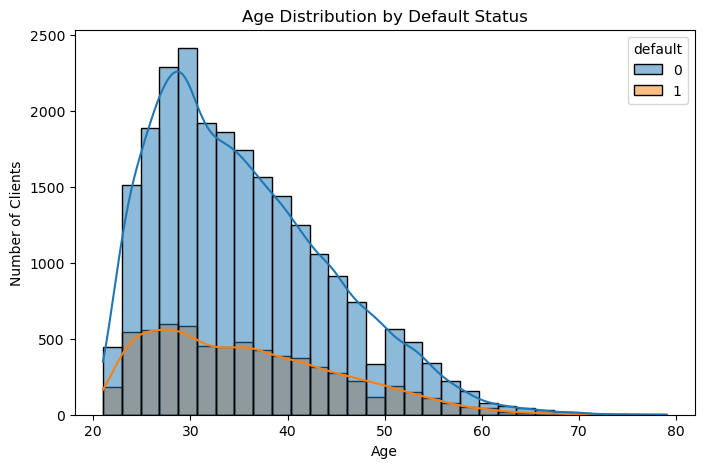

In [6]:
plt.figure(figsize=(8, 5))
sns.histplot(data=credit_df, x="age", hue="default", bins=30, kde=True)
plt.title("Age Distribution by Default Status")
plt.xlabel("Age")
plt.ylabel("Number of Clients")
plt.show()

Nothing to change here!

* **Amount of given credit by defaut status**

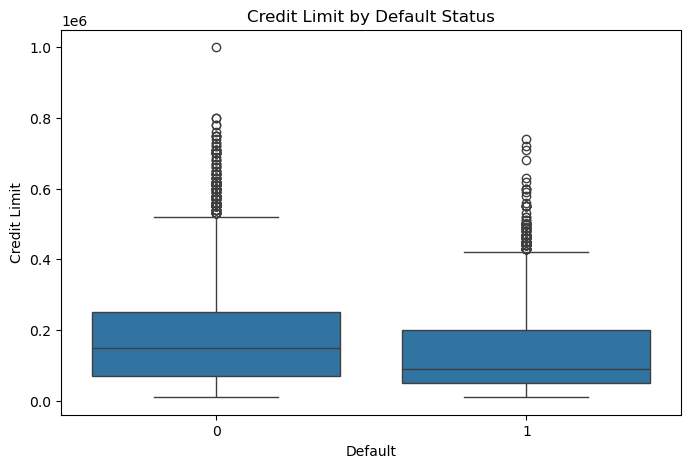

In [7]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=credit_df, x="default", y="limit_bal")
plt.title("Credit Limit by Default Status")
plt.xlabel("Default")
plt.ylabel("Credit Limit")
plt.show()

In [8]:
print(credit_df.groupby("default")["limit_bal"].mean())

default
0    178099.726074
1    130109.656420
Name: limit_bal, dtype: float64


Higher Limits = Lower Risk: Non-defaulters (0) have a significantly higher average credit limit of ~178,100. 
Lower Limits = Higher Risk: Defaulters (1) have a noticeably lower average credit limit of ~130,100 (roughly 27% lower).

The bank assigns lower credit limits to higher-risk customers.

* **Repayment status by defaut**

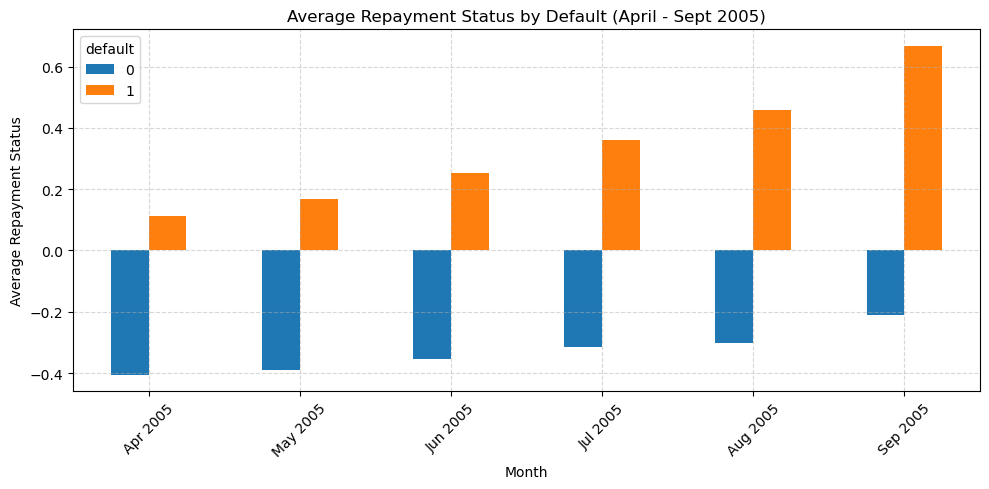

In [9]:
pay_cols = ["pay_6", "pay_5", "pay_4", "pay_3", "pay_2", "pay_0"]
pay_delay_mean = credit_df.groupby("default")[pay_cols].mean().T
#Adding month labels
month_labels = [
    "Apr 2005",
    "May 2005",
    "Jun 2005",
    "Jul 2005",
    "Aug 2005",
    "Sep 2005",]

pay_delay_mean.plot(kind="bar", figsize=(10, 5))
plt.title("Average Repayment Status by Default (April - Sept 2005)")
plt.xlabel("Month")
plt.ylabel("Average Repayment Status")
plt.xticks(rotation=45)
plt.xticks(ticks=range(len(month_labels)), labels=month_labels, rotation=45)
plt.tight_layout()  # Prevents labels from getting cut off at the bottom
plt.grid(True, linestyle="--", alpha=0.5)  
plt.tight_layout()
plt.show()

Customers who eventually defaulted (default = 1) showed clear warning signs months in advance. Their average repayment status steadily worsened over time, climbing from a minor delay in April to a severe peak of over 0.6 months behind by September. Customers who did not default (default = 0) maintained negative average values across all six months, meaning they consistently paid their balances early or on time.

* **Amount of bill statement by default**

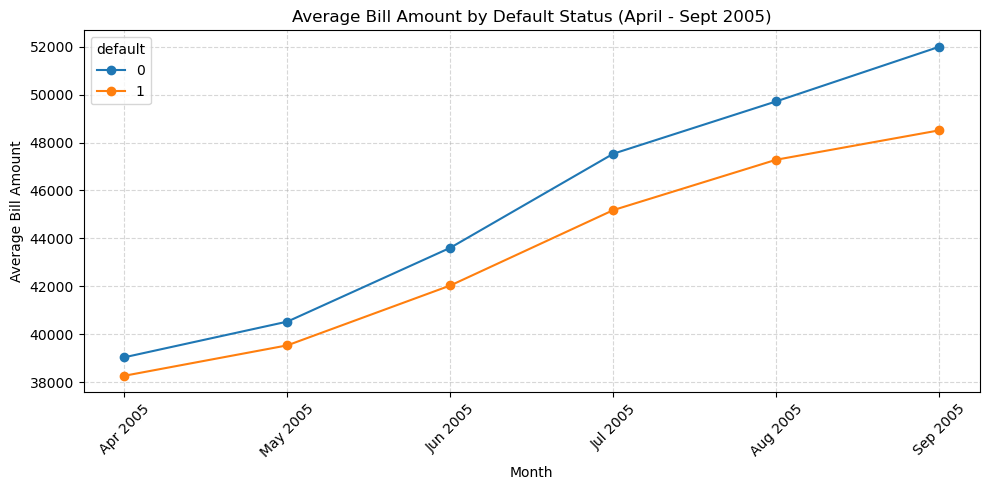

In [10]:
bill_cols = ["bill_amt6", "bill_amt5", "bill_amt4", "bill_amt3", "bill_amt2", "bill_amt1"]
bill_mean = credit_df.groupby("default")[bill_cols].mean().T
#Adding month labels
month_labels = [
    "Apr 2005",
    "May 2005",
    "Jun 2005",
    "Jul 2005",
    "Aug 2005",
    "Sep 2005",]
bill_mean.plot(kind="line", marker="o", figsize=(10, 5))
plt.title("Average Bill Amount by Default Status (April - Sept 2005)")
plt.xlabel("Month")
plt.ylabel("Average Bill Amount")
plt.xticks(ticks=range(len(month_labels)), labels=month_labels, rotation=45)
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)  
plt.tight_layout()
plt.show()

Higher Spending by Non-Defaulters: Surprisingly, customers who did not default (default = 0) consistently carry higher average bill amounts than those who defaulted (default = 1)

The Strategic Takeaway: Defaulters do not necessarily spend more money in raw dollar amounts. Instead, because we previously discovered that defaulters have much lower credit limits, their smaller bill amounts actually consume a much higher percentage of their available credit (higher credit utilization), adding to their financial strain.

* **Payment Amount by Default**

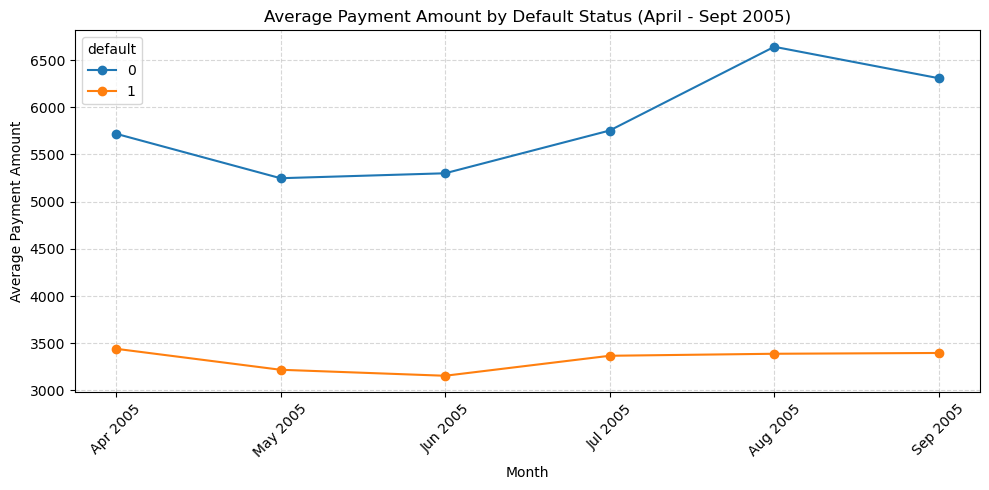

In [11]:
payment_cols = ["pay_amt6", "pay_amt5", "pay_amt4", "pay_amt3", "pay_amt2", "pay_amt1"]
payment_mean = credit_df.groupby("default")[payment_cols].mean().T

month_labels = [
    "Apr 2005",
    "May 2005",
    "Jun 2005",
    "Jul 2005",
    "Aug 2005",
    "Sep 2005",]

payment_mean.plot(kind="line", marker="o", figsize=(10, 5))
plt.title("Average Payment Amount by Default Status (April - Sept 2005)")
plt.xlabel("Month")
plt.ylabel("Average Payment Amount")
plt.xticks(rotation=45)
plt.xticks(ticks=range(len(month_labels)), labels=month_labels, rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

Customers who do not default (default = 0) make significantly larger monthly payments than those who do default (default = 1). Their average payments fluctuate between ~5,200 and ~6,600.
Defaulters maintain a completely flat, low payment trajectory, stagnating around ~3,200 to ~3,500 across all six months.

In [12]:
credit_corr = credit_df.drop(columns=["customer_id", "product_type"]).corr()
credit_corr["default"].sort_values(ascending=False)

default      1.000000
pay_0        0.324794
pay_2        0.263551
pay_3        0.235253
pay_4        0.216614
pay_5        0.204149
pay_6        0.186866
education    0.028006
age          0.013890
bill_amt6   -0.005372
bill_amt5   -0.006760
bill_amt4   -0.010156
bill_amt3   -0.014076
bill_amt2   -0.014193
bill_amt1   -0.019644
marriage    -0.024339
sex         -0.039961
pay_amt6    -0.053183
pay_amt5    -0.055124
pay_amt3    -0.056250
pay_amt4    -0.056827
pay_amt2    -0.058579
pay_amt1    -0.072929
limit_bal   -0.153520
Name: default, dtype: float64

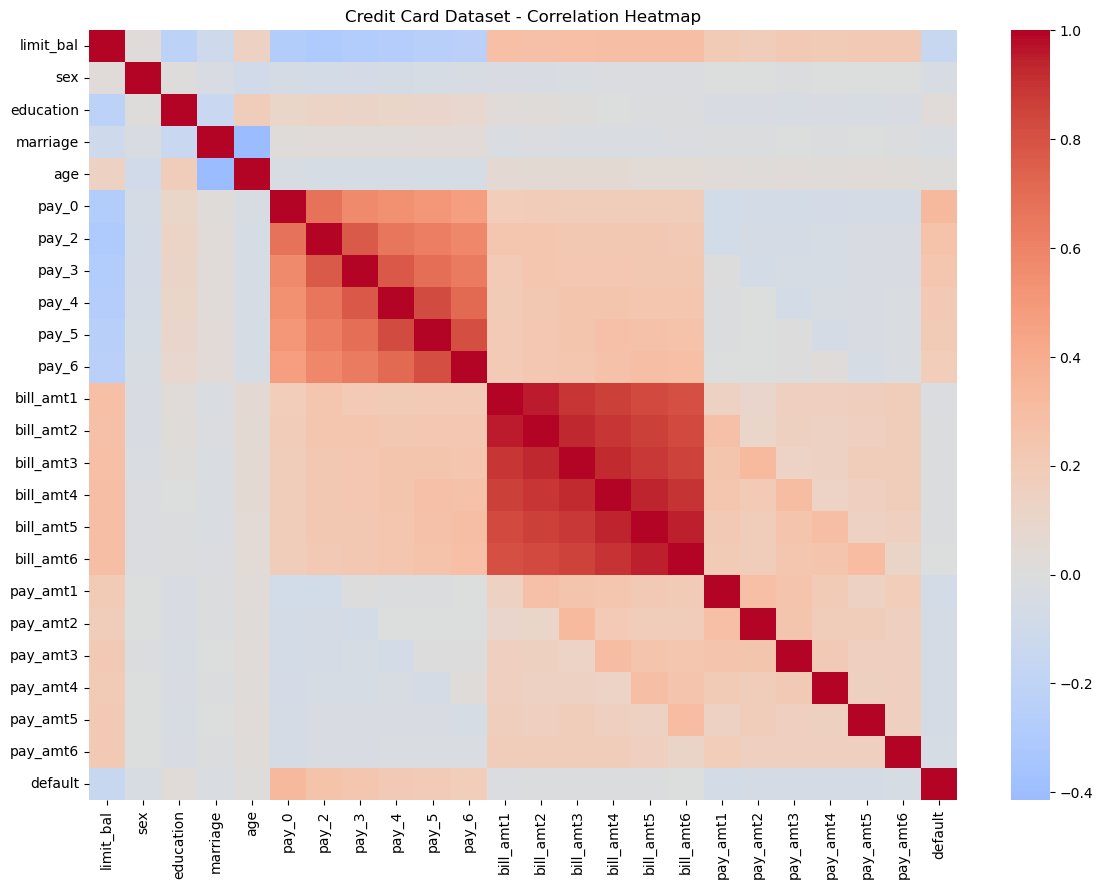

In [125]:
plt.figure(figsize=(14, 10))
sns.heatmap(credit_corr, cmap="coolwarm", center=0)
plt.title("Credit Card Dataset - Correlation Heatmap")
plt.show()

The bill_amt1 through bill_amt6 columns are highly correlated with each other (coefficients close to 0.8 to 1.0). This indicates that a customer’s bill amount from one month is a strong predictor of their bill amount in the next. 

Strong Payment Delay Correlation: The repayment status features (pay_0 through pay_6) also form a distinct block of positive correlation (0.5 to 0.8).A delay in one month strongly correlates with a continued delay in consecutive months.

Predictors for Default: Looking at the bottom row (default), the repayment history columns (pay_0 to pay_6) show the strongest positive correlation (light orange squares). This means as payment delays increase, the probability of default increases.

Negative Correlation with Credit Limit: The limit_bal feature has a weak negative correlation (light blue squares) with both payment delays and target default. This aligns perfectly with your earlier discovery that users with higher credit limits are less likely to default.

### 3. Feature engineering

In [14]:
credit_df["marriage"] = credit_df["marriage"].replace({0: 3}) #  Marriage fix 
credit_df["education"] = credit_df["education"].replace({0: 4, 5: 4, 6: 4}) # Education fix
print(credit_df["marriage"].value_counts())
print(credit_df["education"].value_counts())

## Instead of using all 12 bill/payment variables, create summary variables:

bill_cols = ["bill_amt1", "bill_amt2", "bill_amt3", "bill_amt4", "bill_amt5", "bill_amt6"]
pay_amt_cols = ["pay_amt1", "pay_amt2", "pay_amt3", "pay_amt4", "pay_amt5", "pay_amt6"]

credit_df["avg_bill_amt"] = credit_df[bill_cols].mean(axis=1)
credit_df["max_bill_amt"] = credit_df[bill_cols].max(axis=1)
credit_df["total_bill_amt"] = credit_df[bill_cols].sum(axis=1)

credit_df["avg_pay_amt"] = credit_df[pay_amt_cols].mean(axis=1)
credit_df["max_pay_amt"] = credit_df[pay_amt_cols].max(axis=1)
credit_df["total_pay_amt"] = credit_df[pay_amt_cols].sum(axis=1)

credit_df["payment_to_bill_ratio"] = credit_df["total_pay_amt"] / (credit_df["total_bill_amt"] + 1)


marriage
2    15964
1    13659
3      377
Name: count, dtype: int64
education
2    14030
1    10585
3     4917
4      468
Name: count, dtype: int64


* Encoding variables: marriage, sex, and education

In [15]:
cat_cols = ["sex", "education", "marriage"]

for col in cat_cols:
    credit_df[col] = credit_df[col].astype("category")  # Transforn into categorical variables

num_cols = credit_df.select_dtypes(exclude=["object", "category"]).columns
cat_cols = credit_df.select_dtypes(include=["category"]).columns

print("Numerical columns:", list(num_cols))
print("Categorical columns:", list(cat_cols))

encoder = OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore")
encoded_cat = encoder.fit_transform(credit_df[cat_cols])
encoded_cat_df = pd.DataFrame(
    encoded_cat,
    columns=encoder.get_feature_names_out(cat_cols),
    index=credit_df.index)


Numerical columns: ['customer_id', 'limit_bal', 'age', 'pay_0', 'pay_2', 'pay_3', 'pay_4', 'pay_5', 'pay_6', 'bill_amt1', 'bill_amt2', 'bill_amt3', 'bill_amt4', 'bill_amt5', 'bill_amt6', 'pay_amt1', 'pay_amt2', 'pay_amt3', 'pay_amt4', 'pay_amt5', 'pay_amt6', 'default', 'avg_bill_amt', 'max_bill_amt', 'total_bill_amt', 'avg_pay_amt', 'max_pay_amt', 'total_pay_amt', 'payment_to_bill_ratio']
Categorical columns: ['sex', 'education', 'marriage']


* Defining X and y for the modeling

In [ ]:
X_num = credit_df[num_cols].drop(columns=["customer_id", "default"])
X = pd.concat([X_num, encoded_cat_df], axis=1)
y = credit_df["default"]

,limit_bal,age,pay_0,pay_2,pay_3,pay_4,pay_5,pay_6,bill_amt1,bill_amt2,...,avg_pay_amt,max_pay_amt,total_pay_amt,payment_to_bill_ratio,sex_2,education_2,education_3,education_4,marriage_2,marriage_3
0,20000.0,24,2,2,-1,-1,-2,-2,3913.0,3102.0,...,114.833333,689.0,689.0,0.089422,1.0,1.0,0.0,0.0,0.0,0.0
1,120000.0,26,-1,2,0,0,0,2,2682.0,1725.0,...,833.333333,2000.0,5000.0,0.292774,1.0,1.0,0.0,0.0,1.0,0.0
2,90000.0,34,0,0,0,0,0,0,29239.0,14027.0,...,1836.333333,5000.0,11018.0,0.108387,1.0,1.0,0.0,0.0,1.0,0.0
3,50000.0,37,0,0,0,0,0,0,46990.0,48233.0,...,1398.000000,2019.0,8388.0,0.036259,1.0,1.0,0.0,0.0,0.0,0.0
4,50000.0,57,-1,0,-1,0,0,0,8617.0,5670.0,...,9841.500000,36681.0,59049.0,0.540049,0.0,1.0,0.0,0.0,0.0,0.0


### **5. Models building**

* Train-test split

In [ ]:
# * Two models features accordingly
# Model 1: Full feature model
features_full = [
    "limit_bal", "sex", "education", "marriage", "age",
    "pay_0", "pay_2", "pay_3", "pay_4", "pay_5", "pay_6",
    "bill_amt1", "bill_amt2", "bill_amt3", "bill_amt4", "bill_amt5", "bill_amt6",
    "pay_amt1", "pay_amt2", "pay_amt3", "pay_amt4", "pay_amt5", "pay_amt6"]

# Model 2: Reduced feature model
features_reduced = [
    "limit_bal", "sex", "education", "marriage", "age",
    "pay_0", "pay_2", "pay_3", "pay_4", "pay_5", "pay_6",
    "avg_bill_amt", "max_bill_amt", "total_bill_amt",
    "avg_pay_amt", "max_pay_amt", "total_pay_amt",
    "payment_to_bill_ratio"]

In [40]:
X1 = X.drop(columns=["bill_amt1", "bill_amt2", "bill_amt3", "bill_amt4", "bill_amt5", "bill_amt6",
    "pay_amt1", "pay_amt2", "pay_amt3", "pay_amt4", "pay_amt5", "pay_amt6"])

There is no much difference on setting the first option and second option for feature selection. So I decided to use the features_full for the training models.

In [78]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

* Normalizing process

In [79]:
normalizer = MinMaxScaler()
X_train_norm = normalizer.fit_transform(X_train)
X_test_norm = normalizer.transform(X_test)
X_train_norm = pd.DataFrame(X_train_norm, columns = X_train.columns)
X_test_norm = pd.DataFrame(X_test_norm, columns = X_test.columns)

#### 5.1. **First model: Logistic regression**

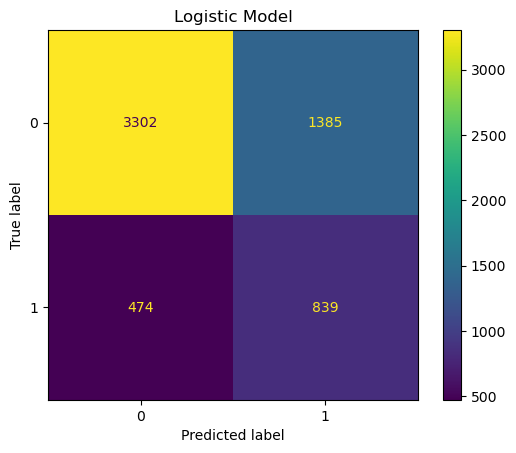

              precision    recall  f1-score   support

           0       0.87      0.70      0.78      4687
           1       0.38      0.64      0.47      1313

    accuracy                           0.69      6000
   macro avg       0.63      0.67      0.63      6000
weighted avg       0.77      0.69      0.71      6000



In [80]:
logistic_model = LogisticRegression(max_iter=1000, class_weight="balanced")
logistic_model.fit(X_train_norm, y_train)
logistic_pred = logistic_model.predict(X_test_norm)

cm = confusion_matrix(y_test, logistic_pred)
ConfusionMatrixDisplay(cm).plot()
plt.title("Logistic Model")
plt.show()

print(classification_report(y_test, logistic_pred))

* SMOTE Sampling

In [81]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(
    X_train_norm,
    y_train)

print(pd.Series(y_train_smote).value_counts())

default
0    18677
1    18677
Name: count, dtype: int64


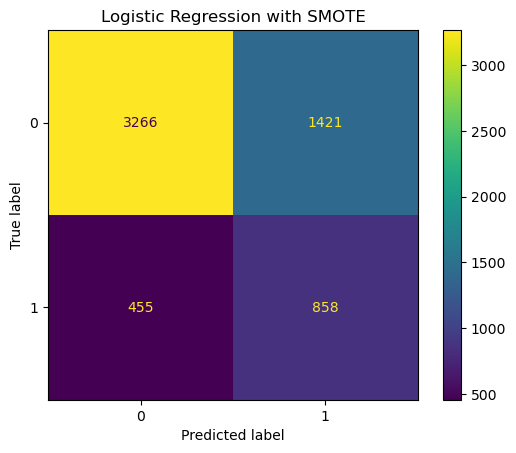

              precision    recall  f1-score   support

           0       0.88      0.70      0.78      4687
           1       0.38      0.65      0.48      1313

    accuracy                           0.69      6000
   macro avg       0.63      0.68      0.63      6000
weighted avg       0.77      0.69      0.71      6000



In [82]:
smote_logistic_model = LogisticRegression(max_iter=1000)
smote_logistic_model.fit(X_train_smote, y_train_smote)
smote_logistic_pred = smote_logistic_model.predict(X_test_norm)

cm = confusion_matrix(y_test, smote_logistic_pred)
ConfusionMatrixDisplay(cm).plot()
plt.title("Logistic Regression with SMOTE")
plt.show()

print(classification_report(y_test, smote_logistic_pred))

Both approaches did not have much differences 

#### 5.2. **Second model: Random Forest Classifier**

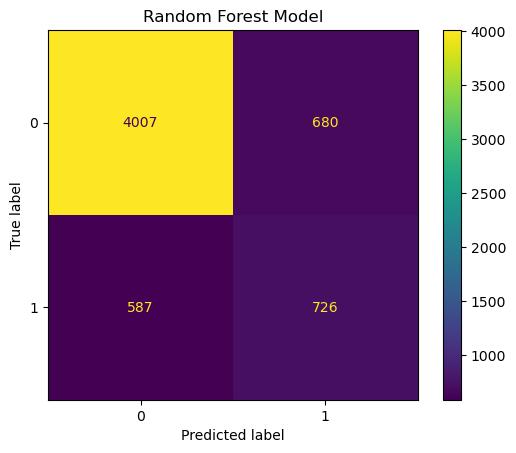

              precision    recall  f1-score   support

           0       0.87      0.85      0.86      4687
           1       0.52      0.55      0.53      1313

    accuracy                           0.79      6000
   macro avg       0.69      0.70      0.70      6000
weighted avg       0.79      0.79      0.79      6000



In [83]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1)

rf_model.fit(X_train_norm, y_train)

rf_pred = rf_model.predict(X_test_norm)

## Confusion Matriy
cm = confusion_matrix(y_test, rf_pred)

ConfusionMatrixDisplay(cm).plot()
plt.title("Random Forest Model")
plt.show()

print(classification_report(y_test, rf_pred))

SMOTE can only help on logistic regressions clasification. Random Forest builds trees by calculating impurity (like Gini or Entropy). Setting class_weight='balanced' modifies this math directly, making mistakes on Class 1 exponentially more expensive. SMOTE often creates artificial blurriness between your features that can actually degrade a Random Forest's precision.

#### 5.3. **Third model: Gradient Boosting Classifier**

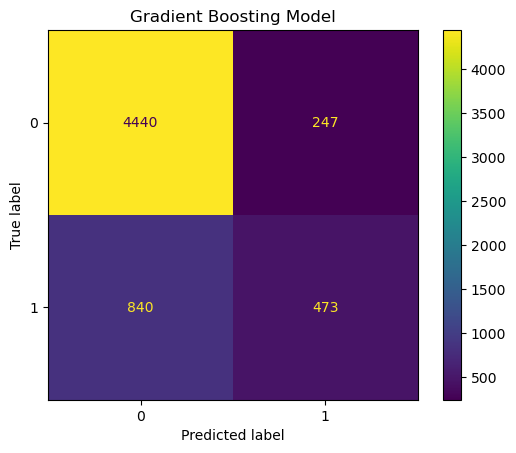

              precision    recall  f1-score   support

           0       0.84      0.95      0.89      4687
           1       0.66      0.36      0.47      1313

    accuracy                           0.82      6000
   macro avg       0.75      0.65      0.68      6000
weighted avg       0.80      0.82      0.80      6000



In [84]:
gb_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42)

gb_model.fit(X_train_norm, y_train)

gb_pred = gb_model.predict(X_test_norm)

##
cm = confusion_matrix(y_test, gb_pred)

ConfusionMatrixDisplay(cm).plot()
plt.title("Gradient Boosting Model")
plt.show()

print(classification_report(y_test, gb_pred))

In [94]:
results = pd.DataFrame({
    "model": [
        "Logistic Regression SMOTE",
        "Random Forest",
        "Gradient Boosting"
    ],
    "accuracy": [
        accuracy_score(y_test, smote_logistic_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, gb_pred)
    ],
    "precision": [
        precision_score(y_test, smote_logistic_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, gb_pred)
    ],
    "recall": [
        recall_score(y_test, smote_logistic_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, gb_pred)
    ],
    "f1_score": [
        f1_score(y_test, smote_logistic_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, gb_pred)
    ],
    "roc_auc": [
        roc_auc_score(y_test, smote_logistic_model.predict_proba(X_test_norm)[:, 1]),
        roc_auc_score(y_test, rf_model.predict_proba(X_test_norm)[:, 1]),
        roc_auc_score(y_test, gb_model.predict_proba(X_test_norm)[:, 1])
    ]
})

results.sort_values(by="f1_score", ascending=False).T

,1,0,2
model,Random Forest,Logistic Regression SMOTE,Gradient Boosting
accuracy,0.788833,0.687333,0.818833
precision,0.516358,0.376481,0.656944
recall,0.552932,0.653465,0.360244
f1_score,0.53402,0.477728,0.465322
roc_auc,0.776296,0.729138,0.782244


Random Forest was selected as the final model because it achieved the best balance between precision and recall, with the highest F1-score among the tested models. Although Logistic Regression with SMOTE had the highest recall, it produced more false positives. Gradient Boosting achieved the highest accuracy and ROC-AUC, but its recall was lower, meaning it missed more default clients. Therefore, Random Forest provides the most balanced performance for credit-risk prediction.

* **Grid/Random Search** for Random Forest

In [96]:
rf_grid = RandomForestClassifier(
    random_state=42,
    class_weight="balanced",
    n_jobs=-1)

# Define hyperparameter grid
grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [5, 10, 15, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]}

random_search = RandomizedSearchCV(
    estimator=rf_grid,
    param_distributions=grid,
    n_iter=20,
    cv=5,
    scoring="f1",
    n_jobs=-1)

random_search.fit(X_train_norm, y_train)

,estimator,RandomForestC...ndom_state=42)
,param_distributions,"{'max_depth': [5, 10, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,n_iter,20
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [ ]:
best_rf_model = random_search.best_estimator_
print("Best parameters:",random_search.best_params_)
print("Best CV score:", random_search.best_score_)

Best parameters: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 10}
Best CV score: 0.5438962583706508


In [99]:
train_score = best_rf_model.score(X_train_norm, y_train)
print("Training accuracy =", train_score)
test_score = best_rf_model.score(X_test_norm, y_test)
print("Test accuracy =", test_score)

Training accuracy = 0.8312916666666667
Test accuracy = 0.7851666666666667


ROC-AUC: 0.7781347705268302
--------------------------------------------
              precision    recall  f1-score   support

           0       0.87      0.85      0.86      4687
           1       0.51      0.56      0.53      1313

    accuracy                           0.79      6000
   macro avg       0.69      0.70      0.70      6000
weighted avg       0.79      0.79      0.79      6000



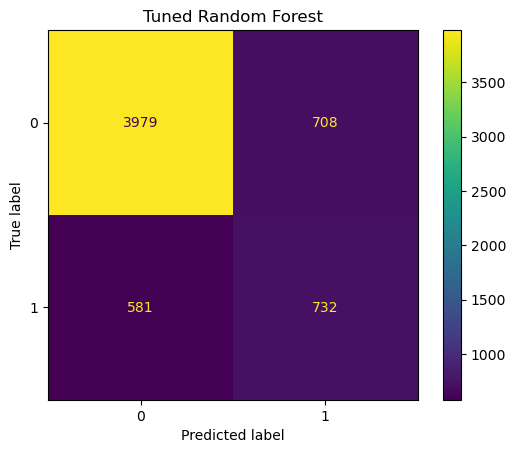

In [ ]:
best_rf_pred = best_rf_model.predict(X_test_norm)
best_rf_proba = best_rf_model.predict_proba(X_test_norm)[:, 1]
print("ROC-AUC:", roc_auc_score(y_test, best_rf_proba))

print("--------------------------------------------")
print(classification_report(y_test, best_rf_pred))

cm = confusion_matrix(y_test, best_rf_pred)
ConfusionMatrixDisplay(cm).plot()
plt.title("Tuned Random Forest")
plt.show()

In [104]:
tuned_results = pd.DataFrame({
    "model": ["Tuned Random Forest"],
    "accuracy": [accuracy_score(y_test, best_rf_pred)],
    "precision": [precision_score(y_test, best_rf_pred)],
    "recall": [recall_score(y_test, best_rf_pred)],
    "f1_score": [f1_score(y_test, best_rf_pred)],
    "roc_auc": [roc_auc_score(y_test, best_rf_proba)]
})

results_final = pd.concat([results, tuned_results], ignore_index=True)

results_final.sort_values(by="f1_score", ascending=False).T

,1,3,0,2
model,Random Forest,Tuned Random Forest,Logistic Regression SMOTE,Gradient Boosting
accuracy,0.788833,0.785167,0.687333,0.818833
precision,0.516358,0.508333,0.376481,0.656944
recall,0.552932,0.557502,0.653465,0.360244
f1_score,0.53402,0.531784,0.477728,0.465322
roc_auc,0.776296,0.778135,0.729138,0.782244


In [106]:
results_final.sort_values(by="f1_score", ascending=False).T.to_csv("Results\Model_comparison_results.csv", index=True) # saving

The Tuned Random Forest was selected as the final model because it provides the best overall balance between detecting default clients and avoiding too many false positives. Although Logistic Regression with SMOTE achieved the highest recall, its precision was much lower. Gradient Boosting achieved the highest accuracy and ROC-AUC, but its recall was too low for a credit-risk problem. The Tuned Random Forest achieved a recall of 0.558, an F1-score of 0.532, and a ROC-AUC of 0.778, making it the most appropriate model for this business case.

POSSIBLE: To make the machine learning workflow more robust, advanced ML workflow concepts were included. Feature engineering was used to summarize highly correlated monthly bill and payment variables. RandomizedSearchCV was applied to tune the Random Forest model. Finally, the selected model can be saved as a reusable object, making the workflow closer to a production-style machine learning process.

In [ ]:
import pickle

with open("Results/Models/tuned_random_forest_credit.pkl", "wb") as file:
    pickle.dump(best_rf_model, file)

import os
os.makedirs("Models", exist_ok=True)

### **Final: Storing data set for the dashboard**

In [121]:
df2 = credit_df.loc[X_test.index].copy()

df2["default_probability"] = best_rf_model.predict_proba(X_test_norm)[:, 1]
df2["predicted_default"] = best_rf_model.predict(X_test_norm)
df2["actual_default"] = y_test.values

def risk_segment(prob):
    if prob >= 0.70:
        return "High Risk"
    elif prob >= 0.40:
        return "Medium Risk"
    else:
        return "Low Risk"

df2["risk_segment"] = df2["default_probability"].apply(risk_segment)
df2.head()

,customer_id,limit_bal,sex,education,marriage,age,pay_0,pay_2,pay_3,pay_4,...,max_bill_amt,total_bill_amt,avg_pay_amt,max_pay_amt,total_pay_amt,payment_to_bill_ratio,default_probability,predicted_default,actual_default,risk_segment
2308,2309,30000.0,1,2,2,25,0,0,0,0,...,14828.0,71631.0,1666.666667,2000.0,10000.0,0.139602,0.427425,0,0,Medium Risk
22404,22405,150000.0,2,1,2,26,0,0,0,0,...,136736.0,635657.0,3311.166667,4486.0,19867.0,0.031254,0.263698,0,0,Low Risk
23397,23398,70000.0,2,3,1,32,0,0,0,0,...,70212.0,417808.0,2672.500000,3112.0,16035.0,0.038379,0.312350,0,0,Low Risk
25058,25059,130000.0,1,3,2,49,0,0,0,0,...,20678.0,90884.0,3646.333333,7014.0,21878.0,0.240722,0.272466,0,0,Low Risk
2664,2665,50000.0,2,2,2,36,0,0,0,0,...,94228.0,243532.0,1216.666667,2000.0,7300.0,0.029975,0.378553,0,1,Low Risk


In [122]:
df2["actual_default_label"] = df2["actual_default"].map({
    0: "No Default",
    1: "Default"
})

df2["predicted_default_label"] = df2["predicted_default"].map({
    0: "Predicted No Default",
    1: "Predicted Default"
})

df2["sex_label"] = df2["sex"].map({
    1: "Male",
    2: "Female"
})

df2["education_label"] = df2["education"].map({
    1: "Graduate School",
    2: "University",
    3: "High School",
    4: "Other / Unknown"
})

df2["marriage_label"] = df2["marriage"].map({
    1: "Married",
    2: "Single",
    3: "Other / Unknown"
})

In [123]:
df2.to_csv("Results/credit_dashboard_predictions.csv", index=False)